# Home assignment

**Implement a simulation of the 2D heat equation with fixed boundaries (using a constant value) in Python and CUDA C/C++ (for the GPU kernel), and visualize the results using matplotlib.pyplot.**

Use the 1D implementation found in `heat_eq_1d_solution.ipynb` as a starting point.

The Julia implementation of the 2D heat equation found in `Webinar_Julia.ipynb` may also be useful.

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from mpl_toolkits.mplot3d import Axes3D
import time

# For the CUDA implementation, install pycuda if needed and import it.
try:
    import pycuda.driver as cuda
    from pycuda.compiler import SourceModule
    import pycuda.autoinit
except ImportError:
    import subprocess
    import sys

    subprocess.check_call([sys.executable, "-m", "pip", "install", "pycuda"])
    import pycuda.driver as cuda
    from pycuda.compiler import SourceModule
    import pycuda.autoinit


## CPU implementation

The following function computes the 2D heat equation using an explicit finite difference stencil. The boundaries are fixed to a constant temperature at each timestep.

In [16]:
def heat_equation_2d(u0, num_timesteps, alpha, dt, dx, dy, fixed_value=0.0):
    u1 = u0.copy()
    ny, nx = u0.shape

    for n in range(num_timesteps):
        for i in range(1, ny - 1):
            for j in range(1, nx - 1):
                u1[i, j] = u0[i, j] + alpha * dt * (
                    (u0[i + 1, j] - 2.0 * u0[i, j] + u0[i - 1, j]) / (dx * dx)
                    + (u0[i, j + 1] - 2.0 * u0[i, j] + u0[i, j - 1]) / (dy * dy)
                )

        u1[0, :] = fixed_value
        u1[-1, :] = fixed_value
        u1[:, 0] = fixed_value
        u1[:, -1] = fixed_value

        u0, u1 = u1, u0

    return u0


## Visualization utilities

These helper functions create 2D heatmap plots and 3D surface plots for the temperature fields.

In [17]:
def plot_temperature(field, title):
    plt.figure(figsize=(6, 5))
    plt.imshow(field, origin="lower", cmap="inferno", interpolation="nearest")
    plt.colorbar(label="Temperature")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()


def plot_temperature_3d(field, title):
    ny, nx = field.shape
    x = np.arange(nx)
    y = np.arange(ny)
    X, Y = np.meshgrid(x, y)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(
        X,
        Y,
        field,
        cmap=cm.inferno,
        linewidth=0,
        antialiased=False,
    )
    fig.colorbar(surf, ax=ax, shrink=0.6, aspect=10, label="Temperature")
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("Temperature")
    plt.show()


## Initial condition

Create an interesting starting temperature distribution with fixed cold boundaries, a central hot Gaussian region, and a secondary hot patch.

In [18]:
def create_initial_temperature(nx, ny, hot_value=1.0, cold_value=0.0):
    T = np.full((ny, nx), cold_value, dtype=np.float32)
    x = np.linspace(-1.0, 1.0, nx)
    y = np.linspace(-1.0, 1.0, ny)
    X, Y = np.meshgrid(x, y)
    radius = np.sqrt(X**2 + Y**2)

    T += hot_value * np.exp(-(radius / 0.3) ** 2)
    patch_size = nx // 10
    T[ny // 4 : ny // 4 + patch_size, nx // 6 : nx // 6 + patch_size] = 0.8 * hot_value

    T[0, :] = cold_value
    T[-1, :] = cold_value
    T[:, 0] = cold_value
    T[:, -1] = cold_value
    return T


# Problem parameters
nx = 128
ny = 128
alpha = 1.0
dx = 1.0
dy = 1.0
fixed_value = 0.0

dt = 0.1
num_timesteps = 100


## CPU execution

Compute the CPU solution using the finite-difference solver and visualize the result with both 2D and 3D plots.

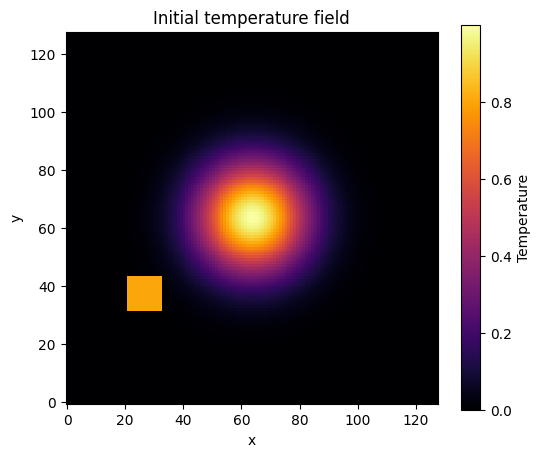

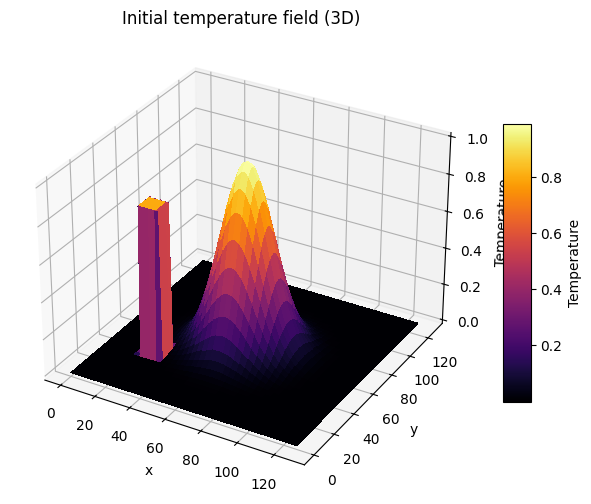

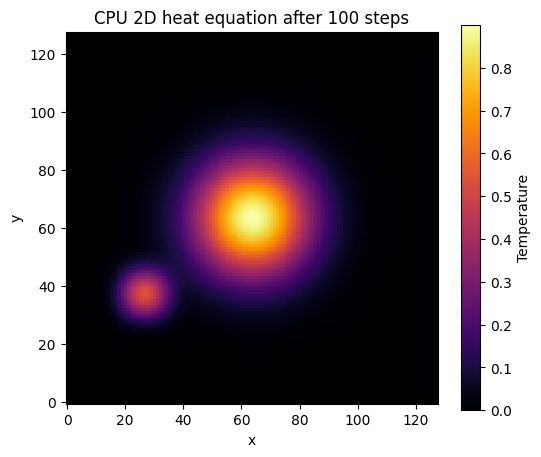

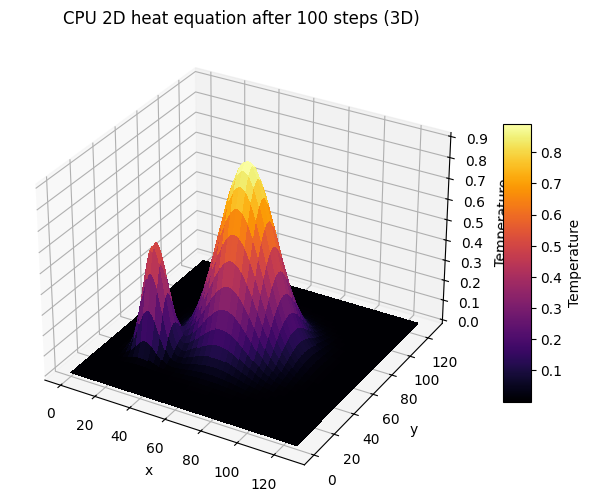

CPU execution time: 2.0709 seconds


In [19]:
initial_temperature = create_initial_temperature(nx, ny, hot_value=1.0, cold_value=fixed_value)

plot_temperature(initial_temperature, "Initial temperature field")
plot_temperature_3d(initial_temperature, "Initial temperature field (3D)")

cpu_start = time.perf_counter()
cpu_final = heat_equation_2d(
    u0=initial_temperature.copy(),
    num_timesteps=num_timesteps,
    alpha=alpha,
    dt=dt,
    dx=dx,
    dy=dy,
    fixed_value=fixed_value,
)
cpu_time = time.perf_counter() - cpu_start


plot_temperature(cpu_final, f"CPU 2D heat equation after {num_timesteps} steps")
plot_temperature_3d(cpu_final, f"CPU 2D heat equation after {num_timesteps} steps (3D)")
print(f"CPU execution time: {cpu_time:.4f} seconds")

## CUDA implementation

Define the CUDA kernel and the GPU solver function. The GPU version applies the same finite-difference update as the CPU version.

In [20]:
heat_eqn_kernel_src = """
__global__ void heatEqn2D(
    float* u1,
    const float* u0,
    float alpha,
    float dx,
    float dy,
    float dt,
    unsigned int nx,
    unsigned int ny,
    float fixed_value
) {
    unsigned int j = blockIdx.x * blockDim.x + threadIdx.x;
    unsigned int i = blockIdx.y * blockDim.y + threadIdx.y;

    if (i >= ny || j >= nx) {
        return;
    }

    unsigned int idx = i * nx + j;

    if (i == 0 || i == ny - 1 || j == 0 || j == nx - 1) {
        u1[idx] = fixed_value;
        return;
    }

    float center = u0[idx];
    float left = u0[idx - 1];
    float right = u0[idx + 1];
    float top = u0[idx - nx];
    float bottom = u0[idx + nx];

    float ddx = (left - 2.0f * center + right) / (dx * dx);
    float ddy = (top - 2.0f * center + bottom) / (dy * dy);
    u1[idx] = center + alpha * dt * (ddx + ddy);
}
"""

mod = SourceModule(heat_eqn_kernel_src)
heatEqn2DGPU = mod.get_function("heatEqn2D")


def heat_equation_2d_gpu(u0, num_timesteps, alpha, dt, dx, dy, fixed_value=0.0):
    assert u0.dtype == np.float32
    ny, nx = u0.shape

    u0_gpu = cuda.mem_alloc(u0.nbytes)
    u1_gpu = cuda.mem_alloc(u0.nbytes)
    cuda.memcpy_htod(u0_gpu, u0)

    block = (16, 16, 1)
    grid = (int(np.ceil(nx / block[0])), int(np.ceil(ny / block[1])), 1)

    for _ in range(num_timesteps):
        heatEqn2DGPU(
            u1_gpu,
            u0_gpu,
            np.float32(alpha),
            np.float32(dx),
            np.float32(dy),
            np.float32(dt),
            np.uint32(nx),
            np.uint32(ny),
            np.float32(fixed_value),
            block=block,
            grid=grid,
        )
        u0_gpu, u1_gpu = u1_gpu, u0_gpu

    u_final = np.empty_like(u0)
    cuda.memcpy_dtoh(u_final, u0_gpu)
    return u_final


## GPU execution and comparison

Run the CUDA version, visualize the result, and compare the CPU and GPU solutions with a numeric error check.

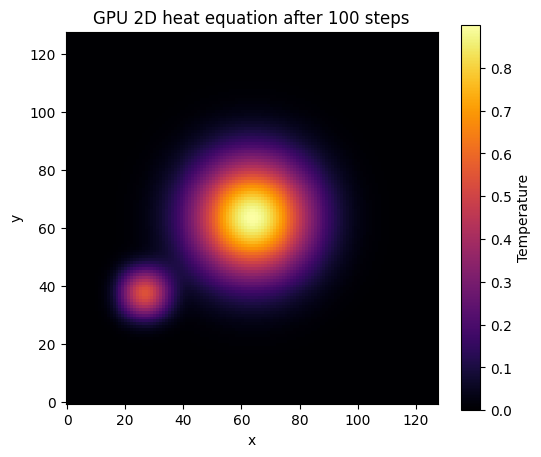

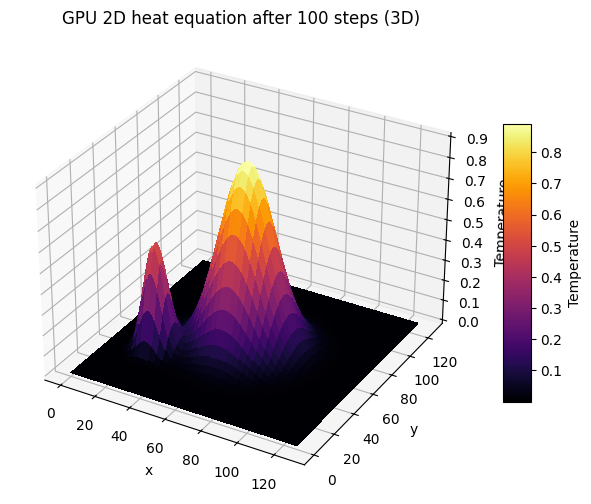

GPU execution time: 0.0040 seconds
Max absolute difference CPU vs GPU: 2.9802322e-07
Speedup: 523.43x


In [21]:
gpu_start = time.perf_counter()
gpu_final = heat_equation_2d_gpu(
    u0=initial_temperature.copy(),
    num_timesteps=num_timesteps,
    alpha=alpha,
    dt=dt,
    dx=dx,
    dy=dy,
    fixed_value=fixed_value,
)
gpu_time = time.perf_counter() - gpu_start

plot_temperature(gpu_final, f"GPU 2D heat equation after {num_timesteps} steps")
plot_temperature_3d(gpu_final, f"GPU 2D heat equation after {num_timesteps} steps (3D)")

max_diff = np.max(np.abs(cpu_final - gpu_final))

print(f"GPU execution time: {gpu_time:.4f} seconds")
print("Max absolute difference CPU vs GPU:", max_diff)
print(f"Speedup: {cpu_time / gpu_time:.2f}x")

## Summary

The notebook documents the 2D heat equation workflow, including CPU and GPU implementations, fixed boundary enforcement, multiple visualization styles, and a numerical comparison between CPU and GPU outputs. The runtime comparison highlights the CPU and GPU execution times and the resulting speedup for the chosen grid and time step configuration.